# Trabajo Práctico 1: Visión por Computadora I

**Carrera de Especialización en Inteligencia Artificial, FIUBA**

#### **Alumno 1:** Lorenzo Fioranelli, Rocío Macarena - a2643
#### **Alumno 2:** Lerner, Federico Ezequiel - a2619
#### **Alumno 3:** Makk, Azul de los Angeles - a2622
#### **Alumno 4:** Moguilner Reh, Nicolás Francisco - a2623

---

El trabajo tiene dos partes independientes:

- **Parte 1:** implementar el algoritmo de White Patch sobre las imágenes de `Material_TPs/TP1/white_patch`, mostrar los resultados y analizar en qué casos falla.
- **Parte 2:** leer `img1_tp.png` e `img2_tp.png` en escala de grises, graficar y comparar sus histogramas, y discutir si el histograma sirve como *feature* para entrenar un modelo.

## Preparación

Las imágenes están en `Material_TPs/TP1/` dentro del repositorio. En lugar de asumir un `cwd` fijo (que depende de desde dónde arranca el kernel: no es lo mismo abrir el notebook con Jupyter clásico, con VS Code o con un kernel remoto), buscamos la carpeta subiendo desde el directorio de trabajo actual hasta encontrarla. Así el notebook corre igual sin importar desde dónde se lo ejecute, siempre que el kernel tenga acceso al repositorio.

In [1]:
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['figure.dpi'] = 90
plt.rcParams['image.interpolation'] = 'nearest'


def buscar_material_tp(nombre_tp='TP1'):
    """Busca Material_TPs/<nombre_tp> subiendo desde el cwd del kernel hasta la raíz del filesystem."""
    for base in [Path.cwd(), *Path.cwd().resolve().parents]:
        candidato = base / 'Material_TPs' / nombre_tp
        if candidato.is_dir():
            return candidato
    raise FileNotFoundError(
        f"No se encontró 'Material_TPs/{nombre_tp}' subiendo desde {Path.cwd()}.\n"
        'Esto suele pasar cuando el kernel corre en un entorno (WSL, remoto, contenedor) sin acceso '
        'al repositorio. Verificá el kernel seleccionado, o definí RUTA a mano con la ruta absoluta '
        'a la carpeta Material_TPs/TP1.'
    )


RUTA = buscar_material_tp('TP1')
RUTA_WP = RUTA / 'white_patch'

print('OpenCV', cv.__version__, '| NumPy', np.__version__)
print('Carpeta de datos encontrada en:', RUTA)
print('Imágenes de white patch:', sorted(p.name for p in RUTA_WP.iterdir()))

OpenCV 5.0.0 | NumPy 2.4.6
Carpeta de datos encontrada en: /Users/federicolerner/Documents/CEIA/3B/VpCI/CEIA-3B-VpC1/Material_TPs/TP1
Imágenes de white patch: ['test_blue.png', 'test_green.png', 'test_red.png', 'wp_blue.jpg', 'wp_green.png', 'wp_green2.jpg', 'wp_red.png', 'wp_red2.jpg']


Un par de utilidades que vamos a reutilizar. La primera es simplemente para no olvidarnos de que OpenCV trabaja en BGR y Matplotlib espera RGB.

In [2]:
def mostrar(img, titulo='', ax=None):
    """Muestra una imagen BGR (OpenCV) o de un solo canal con matplotlib."""
    if ax is None:
        _, ax = plt.subplots()
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
    return ax


def medias_bgr(img):
    """Media de cada canal, en orden B, G, R."""
    return img.reshape(-1, 3).mean(axis=0)


def desbalance(img):
    """Cociente entre la mayor y la menor media de canal (1.0 = medias iguales)."""
    m = np.maximum(medias_bgr(img), 1e-12)
    return float(m.max() / m.min())

---
# Parte 1: Algoritmo White Patch

## 1.1 La idea

El color que mide la cámara no es una propiedad del objeto solamente: es el producto entre la reflectancia de la superficie y el espectro de la fuente de luz. Si iluminamos la misma escena con un LED rojo o con uno azul, los valores RGB cambian por completo aunque el objeto sea el mismo. Los algoritmos de *constancia de color* intentan deshacer ese efecto para quedarnos con algo parecido a la reflectancia.

White Patch (también llamado *Max-RGB* o *White Patch Retinex*) es el más simple de todos. Asume que en la escena hay al menos una superficie blanca (o que refleja bastante en las tres bandas) y que esa superficie es la que produce el máximo de cada canal. Bajo esa hipótesis, la terna

$$(R_{max},\; G_{max},\; B_{max})$$

*es* el color del blanco tal como lo "ve" la cámara bajo esa iluminación, es decir, una estimación del iluminante. Corregir consiste entonces en llevar esa terna al blanco puro $(255, 255, 255)$, escalando cada canal por su propia ganancia:

$$(R, G, B) \;\longrightarrow\; \left(\frac{255}{R_{max}}\,R,\;\; \frac{255}{G_{max}}\,G,\;\;
\frac{255}{B_{max}}\,B\right)$$

Una vez estimadas las ganancias, la corrección es un operador de píxel puntual y lineal sobre cada canal (una ganancia distinta por canal, sin *bias*), del tipo $g(x) = a \cdot f(x)$. El algoritmo completo, en cambio, no es lineal, porque las ganancias salen de los máximos de la propia imagen. Además está muy emparentado con las coordenadas cromáticas: ahí se normaliza cada píxel por $R+G+B$ para que el resultado no dependa del contraste; acá normalizamos toda la imagen por una única terna global para intentar compensar el color de la iluminación.

## 1.2 Implementación

La implementación es de tres líneas, pero conviene hacer las cuentas en punto flotante para no perder precisión ni depender de cómo se promocionan los tipos. Al final recortamos explícitamente a $[0, 255]$ y recién entonces volvemos a `uint8`.

Además de la versión canónica agregamos un parámetro `percentil`, que más adelante nos va a servir para mostrar por qué el máximo es una estimación frágil. Con `percentil=100` se recupera exactamente el algoritmo original.

In [3]:
def white_patch(img, percentil=100):
    """Corrección de iluminación por White Patch.

    img       : imagen BGR uint8
    percentil : percentil por canal usado como estimación del blanco (100 = máximo, algoritmo clásico)

    Devuelve la imagen corregida (uint8) y las ganancias aplicadas en orden B, G, R.
    """
    blanco = np.percentile(img.reshape(-1, 3), percentil, axis=0)
    blanco = np.maximum(blanco, 1.0)          # evita división por cero en un canal apagado
    ganancias = 255.0 / blanco

    corregida = img.astype(np.float32) * ganancias
    return np.clip(corregida, 0, 255).astype(np.uint8), ganancias

Para tener contra qué comparar implementamos también **Gray World**, otra hipótesis clásica. En lugar de suponer que existe un blanco, supone que el promedio de la escena es gris; la ganancia de cada canal es entonces el cociente entre la media global y la media del canal. Es el mismo tipo de operación (una ganancia por canal), pero la estimación del iluminante usa un estadístico de toda la imagen en vez de un único valor extremo por canal.

In [4]:
def gray_world(img):
    """Balance de blancos por hipótesis de mundo gris."""
    medias = np.maximum(medias_bgr(img), 1.0)
    ganancias = medias.mean() / medias
    corregida = img.astype(np.float32) * ganancias
    return np.clip(corregida, 0, 255).astype(np.uint8), ganancias

## 1.3 Resultados

En la carpeta hay dos conjuntos bien distintos: tres imágenes `test_*`, que son la misma escena (unas manos sobre una pared) con tres dominantes de color distintas, y cinco fotos `wp_*` de una figura iluminada con lámparas de color. Los separamos a propósito porque, como se va a ver, el algoritmo se comporta de manera muy distinta en cada grupo.

In [5]:
TESTS = ['test_red.png', 'test_green.png', 'test_blue.png']
FOTOS = ['wp_red.png', 'wp_red2.jpg', 'wp_green.png', 'wp_green2.jpg', 'wp_blue.jpg']

imagenes = {nombre: cv.imread(str(RUTA_WP / nombre)) for nombre in TESTS + FOTOS}

for nombre, img in imagenes.items():
    assert img is not None, f'No se pudo leer {nombre}'
    print(f'{nombre:16s} {img.shape[1]}x{img.shape[0]} px')

test_red.png     276x99 px
test_green.png   278x100 px
test_blue.png    278x100 px
wp_red.png       481x813 px
wp_red2.jpg      1200x1600 px
wp_green.png     363x571 px
wp_green2.jpg    1200x1600 px
wp_blue.jpg      1200x1600 px


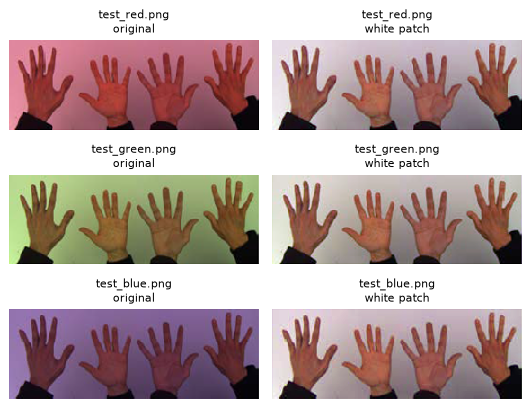

In [6]:
def comparar(nombres, variantes, alto=3.2):
    """Grilla de comparación: una fila por imagen, una columna por variante.

    variantes es una lista de (titulo, funcion) donde la funcion devuelve una imagen BGR.
    """
    fig, axes = plt.subplots(len(nombres), len(variantes),
                             figsize=(3.0 * len(variantes), alto * len(nombres)))
    axes = np.atleast_2d(axes)
    for fila, nombre in enumerate(nombres):
        img = imagenes[nombre]
        for col, (titulo, func) in enumerate(variantes):
            mostrar(func(img), f'{nombre}\n{titulo}', axes[fila, col])
    fig.tight_layout()
    plt.show()


comparar(TESTS,
         [('original', lambda im: im),
          ('white patch', lambda im: white_patch(im)[0])],
         alto=1.6)

En las tres `test_*` el algoritmo hace exactamente lo que promete: las tres salidas quedan prácticamente indistinguibles entre sí, con la piel en un tono creíble y el fondo cercano al gris. Tiene sentido: la pared blanca del fondo cumple al pie de la letra la hipótesis del algoritmo, ninguna de las tres tiene píxeles en 255, y la dominante se comporta como una ganancia por canal, que es justo la transformación que White Patch sabe invertir.

Veamos ahora las fotos reales.

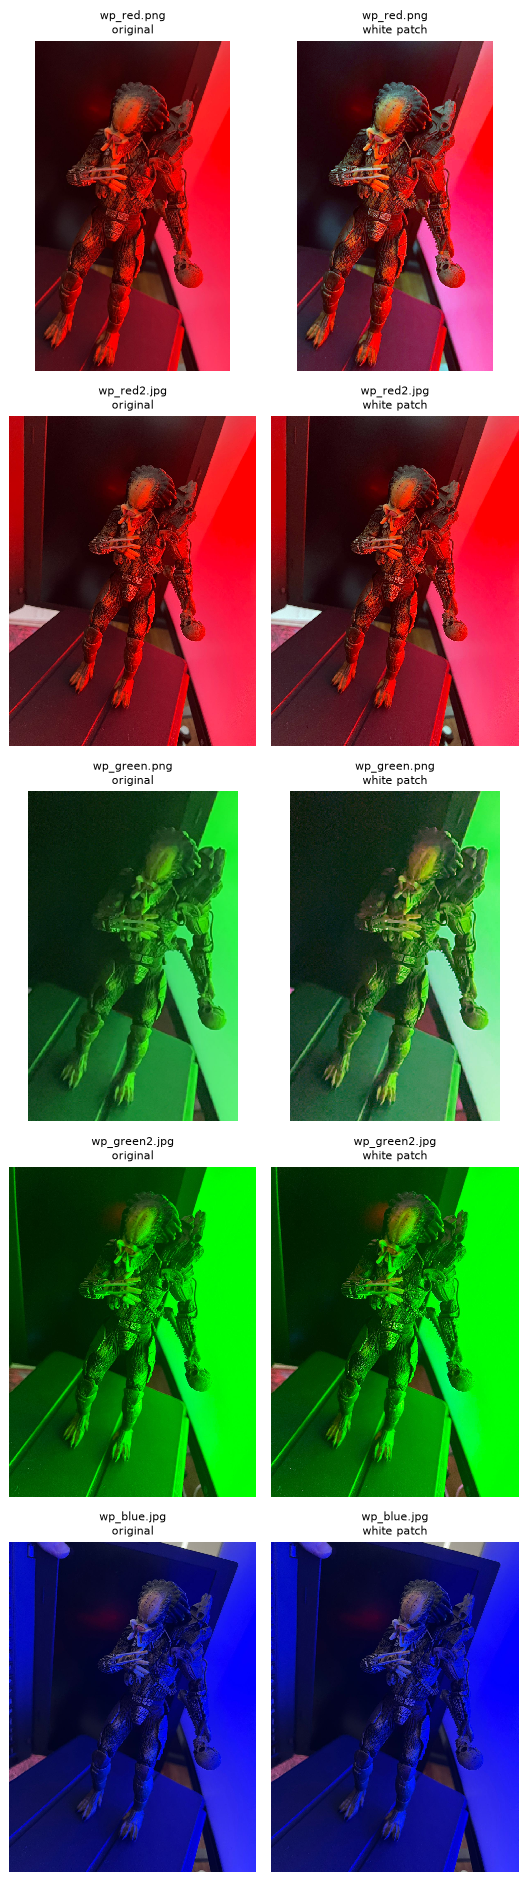

In [7]:
comparar(FOTOS,
         [('original', lambda im: im),
          ('white patch', lambda im: white_patch(im)[0])],
         alto=4.2)

Acá el resultado es mucho peor. `wp_blue.jpg` sale literalmente idéntica a la original, y `wp_red2.jpg` y `wp_green2.jpg` cambian apenas. Sólo `wp_green.png` y `wp_red.png` muestran algo de corrección, y aun así queda una dominante evidente.

## 1.4 ¿Por qué falla? Miremos las ganancias

La ganancia de cada canal depende de un único número: el máximo de ese canal. Si ese máximo ya vale 255, la ganancia es 1 y el canal queda intacto. Tabulemos entonces, para cada imagen, el máximo por canal, la ganancia resultante y qué fracción de píxeles está saturada.

In [8]:
print(f'{"imagen":16s} {"max B,G,R":>16s} {"% sat B,G,R":>22s} {"ganancias B,G,R":>22s}{"desbalance":>19s}')
print('-' * 98)
for nombre in TESTS + FOTOS:
    img = imagenes[nombre]
    plano = img.reshape(-1, 3)
    maximos = plano.max(axis=0)
    saturados = 100.0 * (plano == 255).mean(axis=0)
    corregida, ganancias = white_patch(img)
    print(f'{nombre:16s} {str(maximos):>16s} '
          f'{np.array2string(saturados, precision=3, floatmode="fixed"):>22s} '
          f'{np.array2string(ganancias, precision=2, floatmode="fixed"):>22s}   '
          f'{desbalance(img):6.2f} -> {desbalance(corregida):6.2f}')

imagen                  max B,G,R            % sat B,G,R        ganancias B,G,R         desbalance
--------------------------------------------------------------------------------------------------
test_red.png        [175 157 247]    [0.000 0.000 0.000]       [1.46 1.62 1.03]     1.92 ->   1.22
test_green.png      [171 250 210]    [0.000 0.000 0.000]       [1.49 1.02 1.21]     1.57 ->   1.26
test_blue.png       [200 138 165]    [0.000 0.000 0.000]       [1.27 1.85 1.55]     1.48 ->   1.24
wp_red.png          [122 134 255]    [0.000 0.000 6.460]       [2.09 1.90 1.00]     6.53 ->   3.48
wp_red2.jpg         [203 201 255]    [0.000 0.000 9.104]       [1.26 1.27 1.00]     6.13 ->   4.91


wp_green.png        [155 252 126]    [0.000 0.000 0.000]       [1.65 1.01 2.02]     3.92 ->   1.97
wp_green2.jpg       [172 255 170]    [0.000 5.140 0.000]       [1.48 1.00 1.50]    31.53 ->  22.51


wp_blue.jpg         [255 255 255]    [0.507 0.003 0.001]       [1.00 1.00 1.00]     7.09 ->   7.09


La tabla explica buena parte de lo que pasa. Las tres `test_*` no tienen ni un solo píxel saturado, así que los máximos son informativos y las ganancias son sustanciales (hasta 1.85). En cambio:

- **`wp_blue.jpg` es el caso extremo:** los tres canales llegan a 255, así que las tres ganancias valen 1.0 y la corrección es la identidad. Lo interesante es ver de dónde sale cada máximo. El azul está saturado en unos 9700 píxeles de la pared derecha, algo esperable con un LED azul apuntando ahí. El verde y el rojo, en cambio, llegan a 255 en apenas **54 y 22 píxeles** de un total de 1 920 000, y todos están en un reflejo chiquito sobre el borde de arriba del panel (más abajo lo marcamos sobre la foto). Ese brillo, que casi ni se nota, alcanza para que G y R tampoco se corrijan.
- **`wp_red2.jpg`, `wp_red.png` y `wp_green2.jpg`** tienen el canal dominante saturado en el 9 %, 6 % y 5 % de los píxeles. Ese canal queda fijo con ganancia 1 y sólo se levantan los otros dos, casi siempre poco.
- El desbalance entre las medias de los canales vale 1 cuando las tres medias son iguales. En `wp_blue.jpg` no se mueve ni un decimal: 7.09 antes y 7.09 después. En `wp_red2.jpg` baja de 6.13 a 4.91, que es muy poco. En las `test_*`, en cambio, baja de valores entre 1.5 y 1.9 a alrededor de 1.2.

Las fallas que identificamos, ordenadas por impacto:

**1. Saturación o recorte a 255.** Es el problema dominante en este set. Cuando la luz de color es intensa, el canal correspondiente queda recortado en el máximo representable en regiones extensas. En esas zonas el valor 255 ya no es una medición sino un tope, y el máximo deja de ser un estimador del blanco para pasar a ser una constante. En qué etapa se produjo el recorte no lo podemos saber a partir del archivo final: puede pasar en el sensor, en el ADC o en el procesamiento posterior de la cámara (balance de blancos, curva de gamma, compresión). Lo que sí sabemos es que, una vez recortado, el valor real ya no se puede recuperar.

**2. Sensibilidad a outliers.** El máximo es el estadístico de orden más extremo posible: en cada canal se estima a partir de *un* píxel. Un brillo especular, un píxel caliente, un reflejo, una fuente de luz que entra en cuadro o simplemente ruido impulsivo son suficientes para determinar la ganancia de todo el canal. Es lo que pasa con el reflejo del panel en `wp_blue.jpg`.

**3. La hipótesis puede no cumplirse.** Si en la escena no hay ninguna superficie que refleje bien en las tres bandas, el máximo corresponde a un objeto de color, y "blanquearlo" introduce una dominante nueva en lugar de quitar la existente. Una escena de un bosque, o un plano cerrado de un objeto rojo, rompen el supuesto.

**4. Es una corrección global.** Se aplica una única terna de ganancias a toda la imagen. Si hay dos fuentes de luz de colores distintos, como en estas fotos, donde se mezclan el LED de color y la luz ambiente, no existe una única corrección global que sirva para toda la imagen.

**5. Pérdida de información al recortar la salida.** Después de multiplicar por las ganancias, los valores que superan 255 se recortan. Cuanto mayores son las ganancias, más píxeles se aplastan contra el tope y más se comprime el rango dinámico en las zonas claras.

**6. Amplificación del ruido.** Cuando un canal está muy apagado (en `wp_green2.jpg` el canal B tiene media 4.0 sobre 255) la ganancia necesaria es enorme. Al multiplicar se amplifica el ruido junto con la señal y, como partimos de pocos niveles efectivos, aparece *posterización*: el histograma queda con peine, con huecos entre los niveles ocupados.

Para confirmar lo del reflejo, buscamos en `wp_blue.jpg` los píxeles con G o R en 255 y hacemos zoom sobre esa zona.

Píxeles con G o R saturado: 69
Filas 0 a 28, columnas 842 a 857


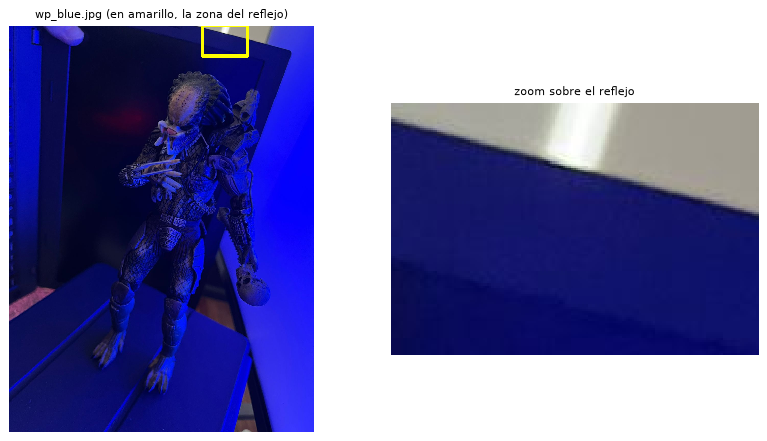

In [9]:
azul = imagenes['wp_blue.jpg']
filas, cols = np.where((azul[:, :, 1] == 255) | (azul[:, :, 2] == 255))
print(f'Píxeles con G o R saturado: {len(filas)}')
print(f'Filas {filas.min()} a {filas.max()}, columnas {cols.min()} a {cols.max()}')

y0, y1 = 0, 120
x0, x1 = cols.min() - 80, cols.max() + 80
marcada = azul.copy()
cv.rectangle(marcada, (int(x0), y0), (int(x1), y1), (0, 255, 255), 12)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [3, 2]})
mostrar(marcada, 'wp_blue.jpg (en amarillo, la zona del reflejo)', axes[0])
mostrar(azul[y0:y1, x0:x1], 'zoom sobre el reflejo', axes[1])
fig.tight_layout()
plt.show()

## 1.5 Análisis adicional: fragilidad ante outliers

La afirmación de que un solo píxel puede romper el algoritmo es fácil de verificar. Tomamos `test_red.png`, que no tiene saturación y donde White Patch funcionaba bien, y le pintamos **un único píxel** blanco en una esquina.

ganancias sin el píxel espurio : [1.457 1.624 1.032]
ganancias con el píxel espurio : [1. 1. 1.]
p99 con el píxel espurio        : [1.564 1.783 1.109]
p99 sin el píxel espurio        : [1.564 1.783 1.109]


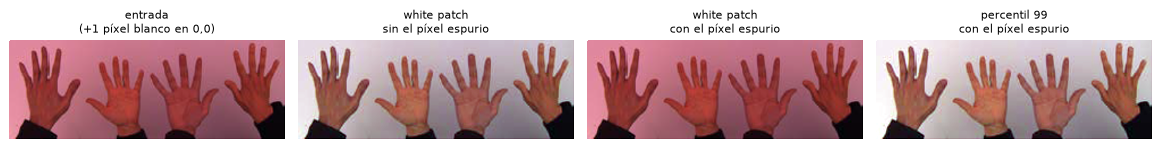

In [10]:
original = imagenes['test_red.png']
contaminada = original.copy()
contaminada[0, 0] = (255, 255, 255)        # un solo píxel, 1 de 27 324

sin_ruido, g_sin = white_patch(original)
con_ruido, g_con = white_patch(contaminada)
robusta, g_rob = white_patch(contaminada, percentil=99)
_, g_rob_limpia = white_patch(original, percentil=99)

print('ganancias sin el píxel espurio :', np.round(g_sin, 3))
print('ganancias con el píxel espurio :', np.round(g_con, 3))
print('p99 con el píxel espurio        :', np.round(g_rob, 3))
print('p99 sin el píxel espurio        :', np.round(g_rob_limpia, 3))

fig, axes = plt.subplots(1, 4, figsize=(13, 2.0))
mostrar(contaminada, 'entrada\n(+1 píxel blanco en 0,0)', axes[0])
mostrar(sin_ruido, 'white patch\nsin el píxel espurio', axes[1])
mostrar(con_ruido, 'white patch\ncon el píxel espurio', axes[2])
mostrar(robusta, 'percentil 99\ncon el píxel espurio', axes[3])
fig.tight_layout()
plt.show()

Modificando 1 píxel de 27 324 (el 0.004 % de la imagen) las tres ganancias caen a 1.0 y la corrección desaparece. Con el percentil 99 pasa otra cosa: las ganancias dan exactamente iguales con el píxel espurio y sin él, porque ese valor queda en la cola que el percentil descarta.

## 1.6 Análisis adicional: una variante robusta

El arreglo natural es reemplazar el máximo por un percentil alto: en vez de tomar como blanco el píxel más brillante, usamos el percentil 99 de cada canal, o sea, el nivel por debajo del cual queda aproximadamente el 99 % de los píxeles. Se conserva la idea del algoritmo pero se descarta la cola de la distribución, que es donde viven los outliers y los píxeles recortados. Comparamos las tres estrategias sobre las fotos reales.

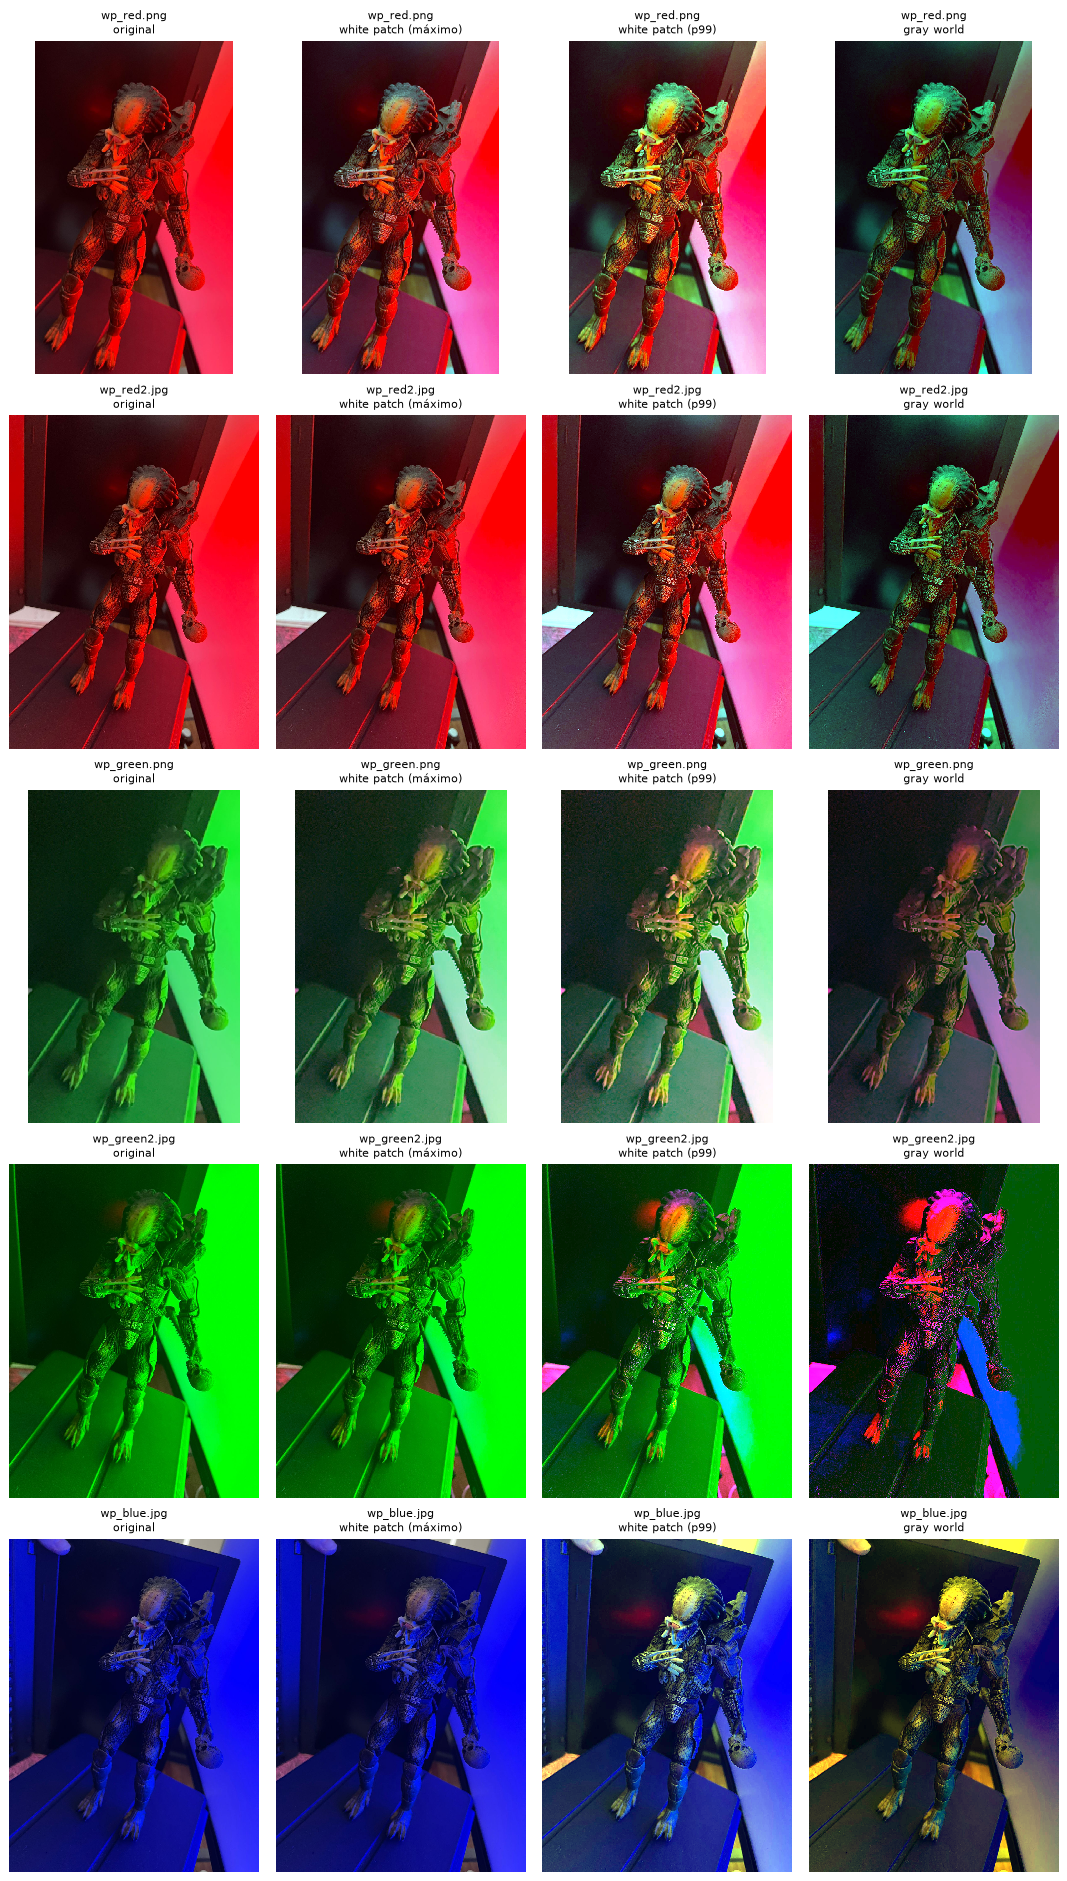

In [11]:
comparar(FOTOS,
         [('original', lambda im: im),
          ('white patch (máximo)', lambda im: white_patch(im)[0]),
          ('white patch (p99)', lambda im: white_patch(im, percentil=99)[0]),
          ('gray world', lambda im: gray_world(im)[0])],
         alto=4.2)

In [12]:
print(f'{"imagen":16s} {"original":>10s} {"máximo":>10s} {"p99":>10s} {"p95":>10s} {"gray world":>12s}')
print('-' * 72)
for nombre in TESTS + FOTOS:
    img = imagenes[nombre]
    fila = [desbalance(img),
            desbalance(white_patch(img)[0]),
            desbalance(white_patch(img, percentil=99)[0]),
            desbalance(white_patch(img, percentil=95)[0]),
            desbalance(gray_world(img)[0])]
    print(f'{nombre:16s} ' + ' '.join(f'{v:10.2f}' for v in fila[:-1]) + f' {fila[-1]:12.2f}')

imagen             original     máximo        p99        p95   gray world
------------------------------------------------------------------------
test_red.png           1.92       1.22       1.21       1.21         1.00
test_green.png         1.57       1.26       1.20       1.20         1.00
test_blue.png          1.48       1.24       1.21       1.20         1.00
wp_red.png             6.53       3.48       1.96       1.75         1.00


wp_red2.jpg            6.13       4.91       2.96       1.60         1.04
wp_green.png           3.92       1.97       1.46       1.42         1.00


wp_green2.jpg         31.53      22.51       8.48       4.93         1.58


wp_blue.jpg            7.09       7.09       3.28       1.70         1.05


El percentil mejora bastante las fotos con saturación moderada y en este set es el mejor compromiso. `wp_green.png` queda bastante más neutra. `wp_blue.jpg` por lo menos se mueve: la figura recupera algo de color, aunque la escena sigue siendo azul y aparecen zonas amarillentas arriba y abajo a la derecha, donde las ganancias de G y R (casi 3 y 2.2) empujan píxeles que ya eran claros. Tampoco hace magia: en `wp_red2.jpg` el canal R está saturado en el 9 % de los píxeles, así que incluso el percentil 95 sigue dando 255 para ese canal y su ganancia sigue siendo 1. Lo que se gana es que los otros dos canales se levantan mucho más (de 1.26 y 1.27 con el máximo a 2.14 con el percentil 99), y eso ya reduce visiblemente la dominante.

La tabla de desbalance, en cambio, conviene leerla con cuidado, porque la métrica no es neutral: mide cuánto se aparta la media de la imagen del gris, que es *exactamente* la hipótesis que Gray World optimiza. Que Gray World dé 1.00 en casi todas las filas sólo quiere decir que resolvió por construcción lo que la métrica mide (donde no da 1, como en `wp_green2.jpg`, es porque después de multiplicar se recortan valores a 255 y las medias dejan de ser iguales). Mirando las imágenes, en varios casos el resultado es malo: en `wp_red.png` y `wp_red2.jpg` la escena está dominada por una pared roja que ocupa medio cuadro, así que forzar la media a gris introduce una dominante cian que antes no existía; y en `wp_green2.jpg` el resultado es directamente irreconocible, con colores arbitrarios y muchísimo ruido, porque hay que multiplicar el canal B, que tiene media 4.0 sobre 255, por un factor cercano a 11. La hipótesis de mundo gris necesita una escena cromáticamente variada, y estas fotos no lo son.

Vale la pena quedarse con esa observación metodológica: una métrica escalar que coincide con la hipótesis de uno de los métodos no sirve para elegir entre métodos. La usamos acá como indicador auxiliar de cuánto se movió la corrección, no como criterio de calidad.

## 1.7 ¿Se iguala la escena bajo las tres luces?

La consigna pide usar White Patch para librarnos de las diferencias de color de la iluminación. En las `test_*` eso se ve directo, porque las tres salidas quedan casi iguales. Con las fotos del Predator podemos hacer la misma prueba: `wp_red2.jpg`, `wp_green2.jpg` y `wp_blue.jpg` tienen la misma resolución y prácticamente el mismo encuadre, así que si la corrección funcionara, las tres versiones corregidas deberían parecerse entre sí.

Para no quedarnos sólo con la impresión visual calculamos también la coordenada cromática media de cada imagen, $(r, g, b) = \left(\frac{R}{R+G+B}, \frac{G}{R+G+B}, \frac{B}{R+G+B}\right)$, y la distancia promedio entre las tres. Dejamos afuera los píxeles muy oscuros ($R+G+B \le 30$), donde el cociente es casi puro ruido.

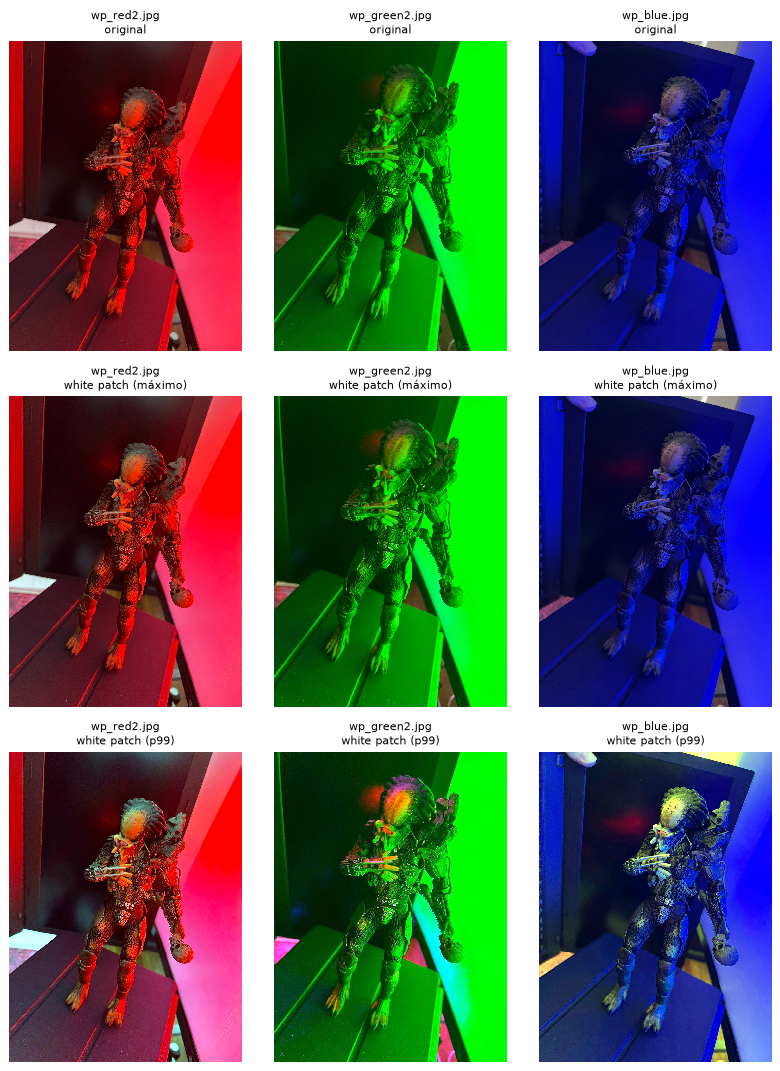

variante                    wp_red2 (r,g,b)    wp_green2 (r,g,b)      wp_blue (r,g,b)  dist. media
--------------------------------------------------------------------------------------------------


original                   [0.73 0.11 0.16]     [0.03 0.94 0.03]     [0.11 0.11 0.79]         1.03


white patch (máximo)       [0.69 0.13 0.18]     [0.04 0.92 0.04]     [0.11 0.11 0.79]         1.00


white patch (p99)          [0.58 0.17 0.25]     [0.06 0.85 0.09]     [0.16 0.22 0.62]         0.76


In [13]:
TRIO = ['wp_red2.jpg', 'wp_green2.jpg', 'wp_blue.jpg']
VARIANTES = [('original', lambda im: im),
             ('white patch (máximo)', lambda im: white_patch(im)[0]),
             ('white patch (p99)', lambda im: white_patch(im, percentil=99)[0])]


def cromaticidad_media(img, umbral=30):
    """Coordenadas cromáticas medias (r, g, b), ignorando los píxeles muy oscuros."""
    px = img.reshape(-1, 3).astype(np.float64)
    suma = px.sum(axis=1)
    validos = suma > umbral
    return (px[validos] / suma[validos, None]).mean(axis=0)[::-1]   # BGR -> rgb


fig, axes = plt.subplots(len(VARIANTES), len(TRIO), figsize=(9, 12))
for fila, (titulo, func) in enumerate(VARIANTES):
    for col, nombre in enumerate(TRIO):
        mostrar(func(imagenes[nombre]), f'{nombre}\n{titulo}', axes[fila, col])
fig.tight_layout()
plt.show()

print(f'{"variante":22s} {"wp_red2 (r,g,b)":>20s} {"wp_green2 (r,g,b)":>20s} {"wp_blue (r,g,b)":>20s} {"dist. media":>12s}')
print('-' * 98)
for titulo, func in VARIANTES:
    crom = [cromaticidad_media(func(imagenes[n])) for n in TRIO]
    dist = np.mean([np.linalg.norm(crom[a] - crom[b]) for a, b in ((0, 1), (0, 2), (1, 2))])
    print(f'{titulo:22s} ' + ' '.join(f'{str(np.round(c, 2)):>20s}' for c in crom) + f' {dist:12.2f}')

Si White Patch hiciera bien su trabajo, la distancia tendría que acercarse a cero. No pasa. Con el máximo apenas baja, de 1.03 a 1.00, y en la figura las tres versiones siguen siendo una roja, una verde y una azul. Cierra con lo que vimos en §1.4: en las tres fotos el canal dominante está recortado en 255, su ganancia queda en 1 y la dominante no se toca. `wp_blue.jpg` directamente no cambia.

Con el percentil 99 la distancia baja a 0.76. Es una mejora, pero las tres siguen teniendo su dominante bien marcada, y `wp_green2.jpg` conserva en promedio un 85 % de verde. Así que, respondiendo a esta parte de la consigna: con estas fotos White Patch no logra librarnos de la iluminación. En las `test_*` sí lo consigue, y la diferencia está en lo que ya listamos: recorte a 255, luces de un color muy puro y más de una fuente en la escena.

## 1.8 Qué le pasa al histograma

Para cerrar la parte 1, miremos los histogramas por canal de un caso intermedio, `wp_green.png`, antes y después de corregir. Es la mejor forma de ver simultáneamente el estiramiento que produce la ganancia y el peine que deja en los canales débiles.

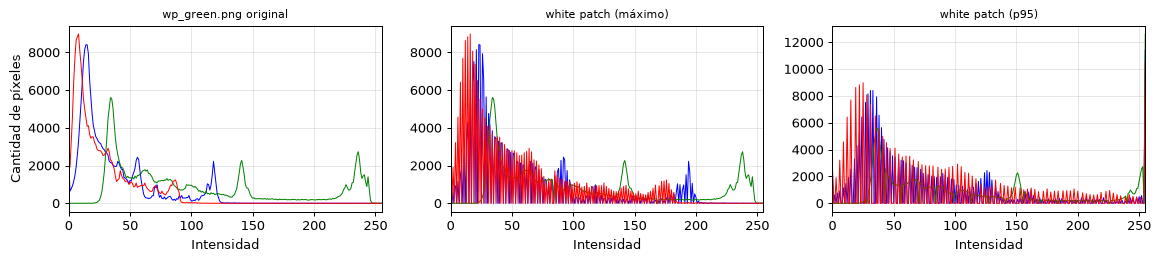

In [14]:
def histogramas_bgr(img, ax, titulo):
    for canal, color in zip(range(3), ('b', 'g', 'r')):
        h = cv.calcHist([img], [canal], None, [256], [0, 256])
        ax.plot(h, color=color, linewidth=0.8)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlim(0, 255)
    ax.set_xlabel('Intensidad')
    ax.grid(alpha=0.3)


img = imagenes['wp_green.png']
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
histogramas_bgr(img, axes[0], 'wp_green.png original')
histogramas_bgr(white_patch(img)[0], axes[1], 'white patch (máximo)')
histogramas_bgr(white_patch(img, percentil=95)[0], axes[2], 'white patch (p95)')
axes[0].set_ylabel('Cantidad de píxeles')
fig.tight_layout()
plt.show()

Se ve con claridad lo que anticipamos: en la original los canales B y R están apretados contra la izquierda (medias de 34.7 y 26.2) mientras que G ocupa casi todo el rango. La corrección los estira, pero estirar no crea niveles nuevos (la cuantización original ya se perdió), así que el histograma de los canales débiles queda con huecos regulares. Es la firma clásica de un aumento de contraste sobre una señal de bajo rango dinámico: el histograma delata la operación que se aplicó. Con el percentil 95 el efecto es más marcado todavía, porque las ganancias son mayores y además aparece un pico en 255 con todo lo que se recortó.

**Conclusión de la Parte 1.** White Patch es atractivo porque es muy barato: alcanza con una pasada por la imagen para buscar los máximos y una multiplicación por píxel. Funciona bien cuando la hipótesis se cumple y la exposición está bien ajustada, como en las `test_*`. En fotos reales con luces de color intensas es poco confiable: depende de un único valor extremo por canal y se rompe justamente cuando la dominante es fuerte, que es cuando más falta haría. En la práctica conviene usar alguna variante robusta (percentil, promediado sobre los píxeles más brillantes, estimación sobre la imagen suavizada) u otro estimador del iluminante como Gray World, que funciona mejor en escenas con colores variados (en estas fotos vimos que no alcanza). Y sobre todo conviene evitar el problema desde la captura: controlando la exposición para que no haya recorte, o incluyendo una carta de grises en la escena.

---
# Parte 2: Histogramas

## 2.1 Lectura y visualización

Leemos las dos imágenes en escala de grises con el flag `cv.IMREAD_GRAYSCALE`. Vale aclarar que `img2_tp.png` viene con canal alfa (es RGBA, aunque el alfa vale 255 en toda la imagen, así que no hay transparencia), y `img1_tp.png` es un PNG de un solo canal; el flag se encarga de unificar ambos casos a una matriz 2D de `uint8`.

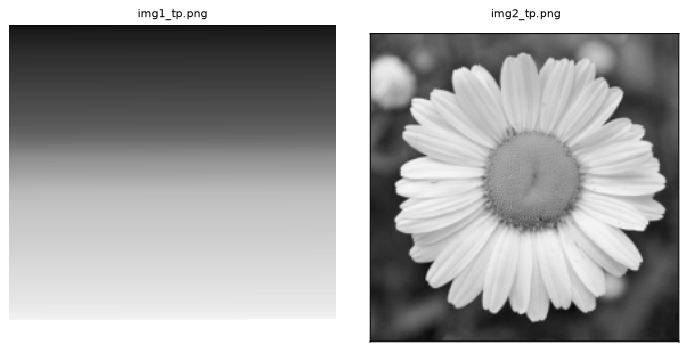

                  shape    dtype   min   max    media      std
img1         (288, 287)    uint8     2   255   154.81    75.34
img2         (288, 287)    uint8     2   255   154.81    75.34


In [15]:
img1 = cv.imread(str(RUTA / 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(str(RUTA / 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

assert img1 is not None, 'No se pudo leer img1_tp.png'
assert img2 is not None, 'No se pudo leer img2_tp.png'

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
mostrar(img1, 'img1_tp.png', axes[0])
mostrar(img2, 'img2_tp.png', axes[1])
fig.tight_layout()
plt.show()

print(f'{"":10s} {"shape":>12s} {"dtype":>8s} {"min":>5s} {"max":>5s} {"media":>8s} {"std":>8s}')
for nombre, im in (('img1', img1), ('img2', img2)):
    print(f'{nombre:10s} {str(im.shape):>12s} {str(im.dtype):>8s} '
          f'{im.min():5d} {im.max():5d} {im.mean():8.2f} {im.std():8.2f}')

Visualmente no podrían ser más distintas: `img1_tp.png` es una rampa vertical de gris que va de casi negro arriba a blanco abajo, sin ninguna estructura; `img2_tp.png` es la foto de una margarita, con pétalos claros, un centro texturado y un fondo oscuro desenfocado. Mirando de cerca, tiene además un marco blanco finito alrededor, que después vamos a ver aparecer en el histograma.

Sin embargo las estadísticas de primer orden ya empiezan a llamar la atención: mismo tamaño (288×287), mismo mínimo, mismo máximo, y media y desvío **exactamente iguales**. Eso no parece casualidad.

## 2.2 Elección del número de bins

La imagen es de 8 bits, con lo cual hay 256 niveles posibles y 288·287 = 82 656 píxeles. Con 256 bins cada bin corresponde exactamente a uno de esos niveles, sin ninguna cuantización extra, así que el histograma describe la distribución completa sin perder nada.

Por eso, **para este TP elegimos 256 bins**, y es lo que usamos en la comparación de §2.3. Recién en §2.5, cuando pensamos el histograma como *feature* de un modelo, bajamos a 32 bins, y ahí el motivo es otro: con menos bins el vector es más chico y menos sensible al ruido. Grafiquemos primero con varias resoluciones para ver cuánto se pierde en cada caso.

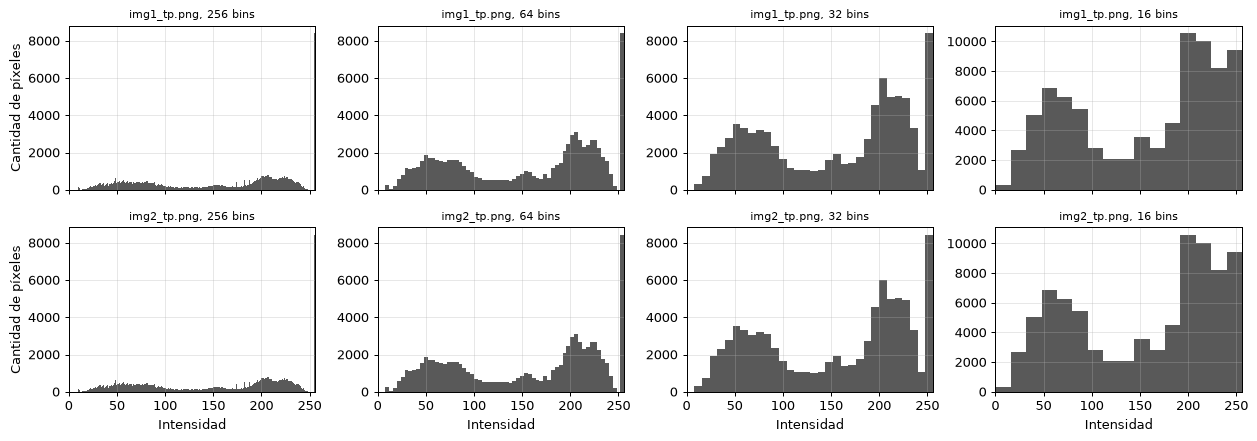

Píxeles en 255: 8400 (10.2 % de la imagen)
Filas enteras en blanco: 16 | columnas enteras en blanco: 14
Píxeles que ocupa el marco: 8400


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True)
for fila, (nombre, im) in enumerate((('img1_tp.png', img1), ('img2_tp.png', img2))):
    for col, bins in enumerate((256, 64, 32, 16)):
        h = cv.calcHist([im], [0], None, [bins], [0, 256]).ravel()
        centros = (np.arange(bins) + 0.5) * 256 / bins
        axes[fila, col].bar(centros, h, width=256 / bins, color='0.35')
        axes[fila, col].set_title(f'{nombre}, {bins} bins', fontsize=9)
        axes[fila, col].set_xlim(0, 256)
        axes[fila, col].grid(alpha=0.3)
    axes[fila, 0].set_ylabel('Cantidad de píxeles')
for ax in axes[1]:
    ax.set_xlabel('Intensidad')
fig.tight_layout()
plt.show()

marco = img2 == 255
filas_blancas = int(marco.all(axis=1).sum())
cols_blancas = int(marco.all(axis=0).sum())
print(f'Píxeles en 255: {marco.sum()} ({100 * marco.mean():.1f} % de la imagen)')
print(f'Filas enteras en blanco: {filas_blancas} | columnas enteras en blanco: {cols_blancas}')
print('Píxeles que ocupa el marco:',
      filas_blancas * img2.shape[1] + cols_blancas * img2.shape[0] - filas_blancas * cols_blancas)

Con 16 bins ya se pierde la estructura fina (los dos picos de la zona clara se funden en uno solo) mientras que con 256 se ve cada nivel por separado, así que es la opción que no esconde nada.

Hay un detalle que no conviene pasar por alto: en el histograma de 256 bins, la barra de la intensidad 255 es la más alta de todas. Son 8400 píxeles, el 10 % de la imagen, y no tienen nada que ver con la margarita. Es el marco blanco de `img2_tp.png`: 16 filas y 14 columnas enteras en 255, que dan justo 16·287 + 14·288 − 16·14 = 8400. O sea que el pico más grande del histograma habla del borde y no del contenido. Igual, lo más llamativo de esta figura es otra cosa: **las dos filas son iguales**.

## 2.3 Comparación de los histogramas

Superponemos ambos histogramas y medimos la diferencia con las métricas de `cv.compareHist`.

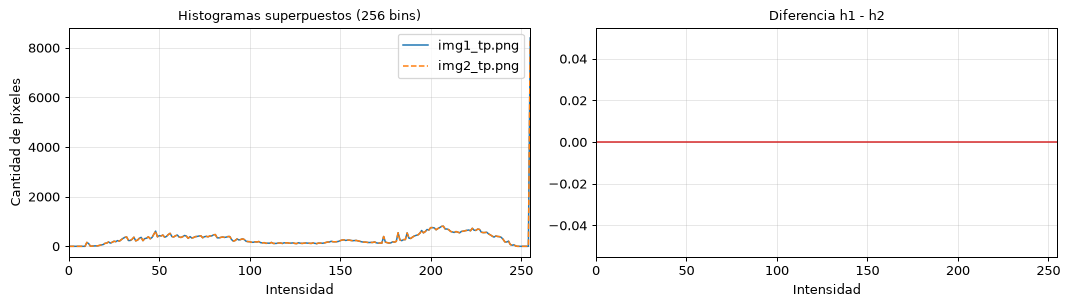

Diferencia máxima entre bins: 0
¿Los histogramas son idénticos? True


In [17]:
BINS = 256
h1 = cv.calcHist([img1], [0], None, [BINS], [0, 256]).ravel()
h2 = cv.calcHist([img2], [0], None, [BINS], [0, 256]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(h1, color='C0', label='img1_tp.png', linewidth=1.2)
axes[0].plot(h2, color='C1', label='img2_tp.png', linewidth=1.2, linestyle='--')
axes[0].set_title(f'Histogramas superpuestos ({BINS} bins)', fontsize=10)
axes[0].set_xlabel('Intensidad')
axes[0].set_ylabel('Cantidad de píxeles')
axes[0].set_xlim(0, 255)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h1 - h2, color='C3', linewidth=1.2)
axes[1].set_title('Diferencia h1 - h2', fontsize=10)
axes[1].set_xlabel('Intensidad')
axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print('Diferencia máxima entre bins:', int(np.abs(h1 - h2).max()))
print('¿Los histogramas son idénticos?', np.array_equal(h1, h2))

In [18]:
# Normalizamos para comparar distribuciones independientemente de la cantidad de píxeles
p1 = (h1 / h1.sum()).astype(np.float32)
p2 = (h2 / h2.sum()).astype(np.float32)

metricas = [('Correlación (1 = idénticos)', cv.HISTCMP_CORREL),
            ('Chi-cuadrado (0 = idénticos)', cv.HISTCMP_CHISQR),
            ('Intersección (1 = idénticos)', cv.HISTCMP_INTERSECT),
            ('Bhattacharyya (0 = idénticos)', cv.HISTCMP_BHATTACHARYYA)]

for etiqueta, metodo in metricas:
    print(f'{etiqueta:34s} {cv.compareHist(p1, p2, metodo):10.6f}')

Correlación (1 = idénticos)          1.000000
Chi-cuadrado (0 = idénticos)         0.000000
Intersección (1 = idénticos)         1.000000
Bhattacharyya (0 = idénticos)        0.000000


Los histogramas son **exactamente iguales**, bin por bin. Las cuatro métricas dan el valor de coincidencia perfecta.

## 2.4 Por qué pasa esto

Si los histogramas son idénticos, entonces las dos imágenes tienen exactamente la misma multiplicidad de cada nivel de gris, es decir, una es una **permutación de los píxeles** de la otra. Y de hecho es fácil verificar cuál: `img1_tp.png` es la lista de píxeles de `img2_tp.png` ordenada de menor a mayor intensidad y reacomodada en la misma grilla.

¿reconstruida == img1? True
Error absoluto máximo  : 0
Píxeles distintos entre img1 e img2: 96.2 %


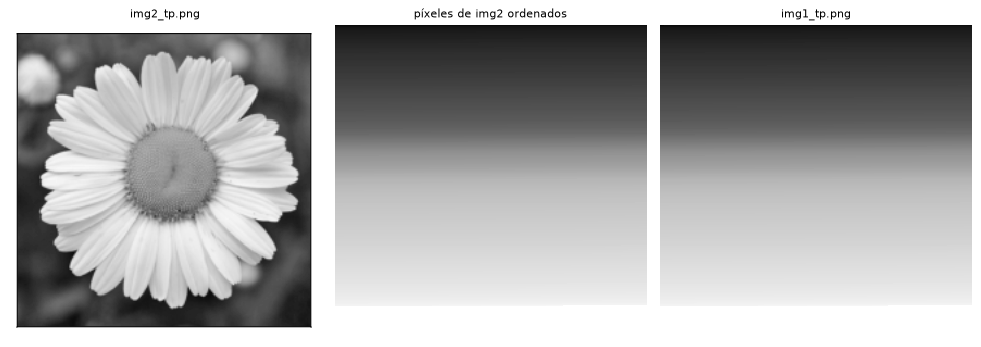

In [19]:
# Ordenamos todos los píxeles de la margarita y los reacomodamos en una matriz del mismo tamaño
reconstruida = np.sort(img2.ravel()).reshape(img2.shape)

print('¿reconstruida == img1?', np.array_equal(reconstruida, img1))
print('Error absoluto máximo  :', int(np.abs(reconstruida.astype(int) - img1.astype(int)).max()))
print('Píxeles distintos entre img1 e img2: '
      f'{100 * (img1 != img2).mean():.1f} %')

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
mostrar(img2, 'img2_tp.png', axes[0])
mostrar(reconstruida, 'píxeles de img2 ordenados', axes[1])
mostrar(img1, 'img1_tp.png', axes[2])
fig.tight_layout()
plt.show()

La reconstrucción coincide con `img1_tp.png` píxel a píxel (error máximo 0), aunque en el 96 % de las posiciones `img1` e `img2` tienen valores distintos. Las imágenes del TP están armadas justamente para ilustrar esto: el histograma cuenta *cuántos* píxeles hay de cada intensidad, pero descarta por completo *dónde* están. Formalmente, es invariante ante cualquier permutación de los píxeles: espejados, rotaciones de 90° y también permutaciones sin ningún sentido visual como ésta. Con rotaciones en ángulos arbitrarios o cambios de escala deja de ser exacto, porque la interpolación crea niveles nuevos. Puede mantenerse parecido, pero eso depende de la interpolación y de qué se haga con los bordes.

Si en cambio usamos algo que mire la vecindad de cada píxel, como los filtros de Sobel y el Laplaciano, las dos imágenes se separan enseguida:

In [20]:
def estadisticos_espaciales(im):
    gx = cv.Sobel(im, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(im, cv.CV_64F, 0, 1, ksize=3)
    return np.sqrt(gx ** 2 + gy ** 2).mean(), cv.Laplacian(im, cv.CV_64F).var()

print(f'{"":8s} {"|gradiente| medio":>20s} {"varianza del laplaciano":>26s}')
for nombre, im in (('img1', img1), ('img2', img2)):
    g, l = estadisticos_espaciales(im)
    print(f'{nombre:8s} {g:20.2f} {l:26.2f}')

            |gradiente| medio    varianza del laplaciano
img1                     6.69                       2.22
img2                    65.55                    1233.45


En `img2` el gradiente medio es casi 10 veces mayor y la varianza del laplaciano unas 550 veces mayor, aunque las dos imágenes tienen exactamente la misma distribución de intensidades.

## 2.5 ¿Sirven los histogramas como features?

La respuesta corta es que sirven, pero no solos y no en cualquier problema. Vale la pena separar las ventajas de las limitaciones, porque las dos son consecuencia de la misma propiedad: el histograma marginaliza la posición.

**A favor:**

- Es barato: una pasada sobre la imagen, $O(N)$, y el vector resultante es chico (256, 64 o 32 números según la cuantización elegida).
- Es de tamaño fijo, independiente de la resolución de la imagen (normalizando por la cantidad de píxeles), lo cual es cómodo para alimentar clasificadores clásicos tipo SVM o random forest.
- No cambia ante transformaciones que sólo reordenan los píxeles, como espejados o rotaciones de 90°, y ante rotaciones arbitrarias o cambios de escala puede mantenerse parecido, aunque depende de la interpolación y del tratamiento de los bordes. En problemas donde el color o la distribución global de intensidades alcanzan para distinguir clases (tipos de tejido, frutas maduras o no, tomas de día y de noche, control de calidad sobre un fondo controlado), un histograma de color en HSV puede ser un buen punto de partida.
- Es interpretable y sirve para diagnosticar el dataset: sub o sobreexposición, bajo rango dinámico, cuantización, cambios de iluminación entre lotes de imágenes.

**En contra:**

- No codifica ninguna información espacial, que es precisamente lo que demuestra este ejercicio. Dos imágenes con contenido semántico completamente distinto pueden tener histogramas idénticos, así que ningún clasificador que reciba sólo el histograma va a poder separarlas. Para tareas de reconocimiento de forma o de detección de objetos, esa limitación es fatal.
- Es muy sensible a la iluminación y a la exposición: un cambio de ganancia o de *bias* desplaza y escala el histograma completo, aunque la escena sea la misma. Esto lo vimos de primera mano en la Parte 1. Si se lo va a usar como feature, conviene normalizar antes (balance de blancos, ecualización o coordenadas cromáticas, que son invariantes al contraste) o el modelo va a terminar aprendiendo la iluminación en vez del objeto.
- Cuenta todo lo que hay en la imagen, sea parte del objeto o no. Acá el marco blanco se lleva el 10 % del histograma, y en un dataset real pasa lo mismo con el padding, las marcas de agua o el fondo. Conviene recortar antes, o pasarle una máscara a `calcHist`, que la acepta como tercer argumento.
- La elección de bins introduce un hiperparámetro con un compromiso real: muchos bins dan un descriptor ruidoso y de alta dimensión, pocos bins descartan información. Para usarlo como feature, 32 o 64 bins suele ser un buen punto de partida.
- En detección no aplica directamente, porque no localiza nada.

**Prueba adicional: histogramas por bloques.** Una forma sencilla de conservar las ventajas y mitigar la limitación principal es reintroducir la información espacial: calcular histogramas **locales** sobre una grilla de bloques y concatenarlos. La idea general se relaciona con descriptores como HOG y LBP. Probémoslo con una grilla de 4×4 sobre nuestras dos imágenes.

Dimensión del descriptor: 512
Distancia L1 entre descriptores globales (32 bins): 0.0
Distancia L1 entre descriptores por bloques      : 24.961881637573242


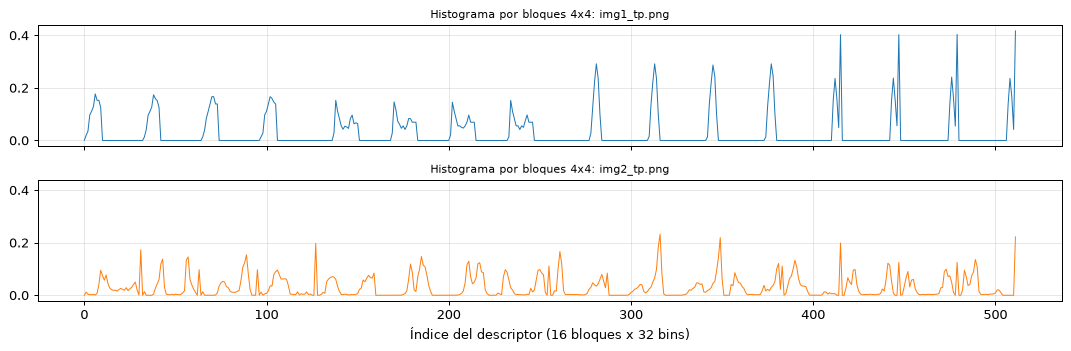

In [21]:
def histograma_por_bloques(im, grilla=4, bins=32):
    """Concatena los histogramas normalizados de cada bloque de una grilla."""
    alto, ancho = im.shape
    partes = []
    for i in range(grilla):
        for j in range(grilla):
            bloque = im[i * alto // grilla:(i + 1) * alto // grilla,
                        j * ancho // grilla:(j + 1) * ancho // grilla]
            h = cv.calcHist([bloque], [0], None, [bins], [0, 256]).ravel()
            partes.append(h / max(h.sum(), 1))
    return np.concatenate(partes).astype(np.float32)


f1 = histograma_por_bloques(img1)
f2 = histograma_por_bloques(img2)
print('Dimensión del descriptor:', f1.shape[0])
print('Distancia L1 entre descriptores globales (32 bins):',
      float(np.abs(cv.calcHist([img1], [0], None, [32], [0, 256]).ravel() / img1.size -
                   cv.calcHist([img2], [0], None, [32], [0, 256]).ravel() / img2.size).sum()))
print('Distancia L1 entre descriptores por bloques      :', float(np.abs(f1 - f2).sum()))

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True, sharey=True)
axes[0].plot(f1, color='C0', linewidth=0.8)
axes[0].set_title('Histograma por bloques 4x4: img1_tp.png', fontsize=9)
axes[1].plot(f2, color='C1', linewidth=0.8)
axes[1].set_title('Histograma por bloques 4x4: img2_tp.png', fontsize=9)
for ax in axes:
    ax.grid(alpha=0.3)
axes[1].set_xlabel('Índice del descriptor (16 bloques x 32 bins)')
fig.tight_layout()
plt.show()

El histograma global da distancia 0 y el de bloques da 24.96, sobre un máximo posible de 32 (16 bloques normalizados, cada uno aporta como mucho 2): con sólo dividir la imagen en 16 celdas el descriptor pasa de no distinguirlas a separarlas con claridad. En `img1` se ve la estructura de la rampa: como la rampa es vertical, los cuatro bloques de cada fila de la grilla tienen casi el mismo histograma (el mismo pico y el mismo rango de valores), y el pico se va corriendo hacia intensidades más altas de una fila a la siguiente. En `img2`, en cambio, la distribución de cada celda depende de si cayó sobre el fondo oscuro o sobre los pétalos.

**Respondiendo la pregunta del enunciado:** sí, los histogramas pueden ser una feature útil, y de hecho son un buen punto de partida por su costo y su interpretabilidad, pero **como descriptor global son insuficientes para clasificación o detección** salvo en problemas donde la distribución de intensidad o de color sea por sí sola discriminante. Este par de imágenes lo muestra bien: cualquier persona las distingue al instante, pero para un modelo que reciba sólo el histograma son la misma imagen. Si se van a usar, conviene (a) normalizar la iluminación antes, (b) localizarlos por bloques o regiones, y (c) combinarlos con descriptores que capturen estructura espacial, como bordes, gradientes o puntos característicos.

---
## Conclusiones

**Parte 1.** Implementamos White Patch como una ganancia por canal estimada a partir del máximo de cada uno. Aplicada a cada píxel la corrección es lineal, pero las ganancias dependen de la imagen. Funciona muy bien en las tres imágenes `test_*`, donde ningún canal llega a 255 y la dominante es efectivamente una ganancia por canal. En las cinco fotos reales rinde bastante peor, y una de las causas se puede medir: cuando un canal está recortado, su máximo vale 255 y su ganancia pasa a ser 1. El caso límite es `wp_blue.jpg`: el azul está recortado en 255 sobre la pared y un reflejo chiquito lleva también al verde y al rojo a 255 (54 y 22 píxeles), así que las tres ganancias quedan en 1 y la corrección termina siendo la identidad. Verificamos además, con un experimento controlado, que alcanza con un único píxel espurio para romper el algoritmo. Reemplazar el máximo por un percentil alto lo vuelve bastante más robusto sin cambiar la idea, y es lo que mejor resultado visual dio acá. Aun así, cuando comparamos la misma escena bajo luz roja, verde y azul, ninguna de las dos versiones consigue que las tres queden parecidas. Gray World iguala las medias de los canales por construcción, pero el recorte posterior a 255 y el hecho de que su hipótesis no se cumpla pueden arruinar el resultado. En estas escenas, dominadas por un color que ocupa medio cuadro, sobrecorrige e introduce dominantes nuevas, así que un desbalance cercano a 1 no alcanza para declararlo ganador.

**Parte 2.** Los histogramas de `img1_tp.png` e `img2_tp.png` son exactamente iguales a pesar de que las imágenes no tienen nada que ver entre sí: la primera es la segunda con los píxeles ordenados por intensidad, cosa que comprobamos reconstruyéndola. También vimos que el 10 % de ese histograma es el marco blanco de la imagen, que no aporta nada sobre el contenido. El ejercicio deja clara la propiedad central del histograma: no cambia si se reordenan los píxeles. Para el diseño de features eso tiene dos caras. Como descriptor global es barato y no le afectan los espejados ni las rotaciones de 90°, pero es ambiguo, y hay que localizarlo o combinarlo con descriptores estructurales para que sirva en clasificación o detección.